In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy.linalg as la

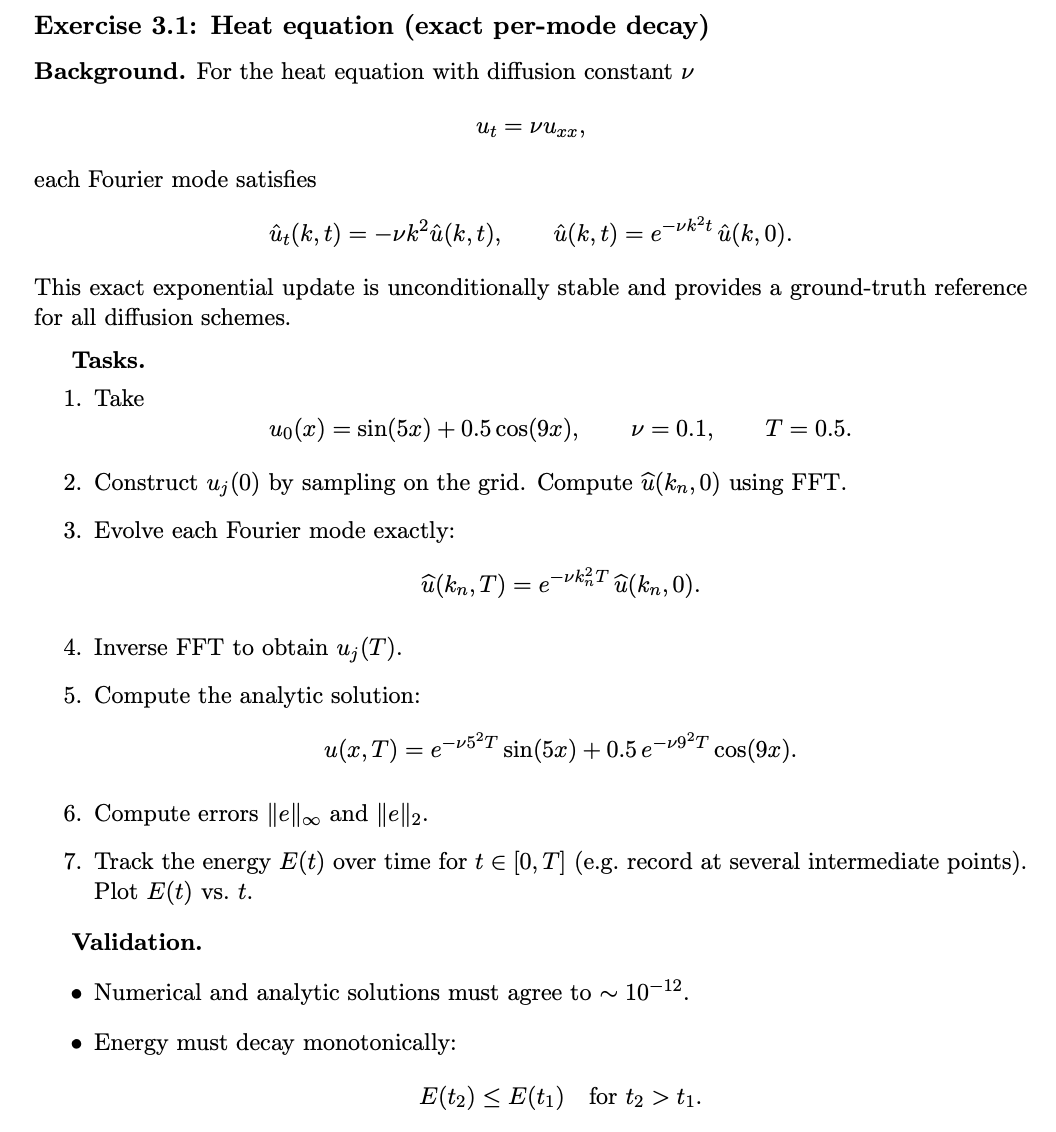

In [3]:
def u_0(x):
    return np.sin(5*x) + (1/2)*np.cos(9*x)

nu = 0.1
T = 0.5
L=2*np.pi
N = 128

# Sampling + FFT 
x_j = np.arange(N) * (L/N)
sampled_array = u_0(x_j)
u_hat_k_n = np.fft.fft(sampled_array)

# Evolving fourier modes exactly
k_n = 2*np.pi*np.fft.fftfreq(N,L/N)
u_hat_k_n_T = np.exp(-nu*k_n**2*T)*u_hat_k_n

# Inverse FFT to obtain u_j(T)
inv_u_hat_k_n_T = np.fft.ifft(u_hat_k_n_T).real

# Analytic solution
u_x_T = np.exp(-nu*25*T)*np.sin(5*x_j) + (1/2)*np.exp(-nu*81*T)*np.cos(9*x_j)

# Errors - L2 and L_inf
error = u_x_T - inv_u_hat_k_n_T
error_l2 = la.norm(error, ord=2)/np.sqrt(N)
error_inf = la.norm(error, ord=np.inf)

print(f"L2 norm of the error: {error_l2}")
print(f"L_inf norm of the error: {error_inf}")

L2 norm of the error: 2.592699537894845e-16
L_inf norm of the error: 8.118505867571457e-16


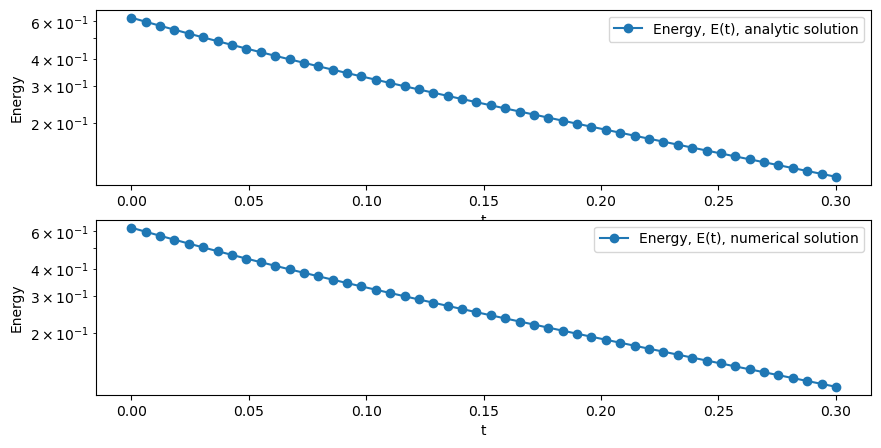

In [17]:
# Plotting E(t) Vs t
E_t_ana,E_t_num = [],[]
for t in np.linspace(0,T):
    u_x_T = np.exp(-nu*25*t)*np.sin(5*x_j) + (1/2)*np.exp(-nu*81*t)*np.cos(9*x_j)
    
    u_hat_k_n_T = np.exp(-nu*k_n**2*t)*u_hat_k_n
    inv_u_hat_k_n_T = np.fft.ifft(u_hat_k_n_T).real

    E_t_ana.append((1/N)*np.sum(np.abs(u_x_T)**2))
    E_t_num.append((1/N)*np.sum(np.abs(inv_u_hat_k_n_T)**2))


fig, ax = plt.subplots(nrows = 2,ncols = 1,
                      figsize =(10, 5))

ax[0].semilogy(np.linspace(0,T), E_t_ana, marker="o", label="Energy, E(t), analytic solution")
ax[0].set_xlabel("t")
ax[0].set_ylabel("Energy")
ax[0].legend()

ax[1].semilogy(np.linspace(0,T), E_t_num, marker="o", label="Energy, E(t), numerical solution")
ax[1].set_xlabel("t")
ax[1].set_ylabel("Energy")
ax[1].legend()

plt.show()

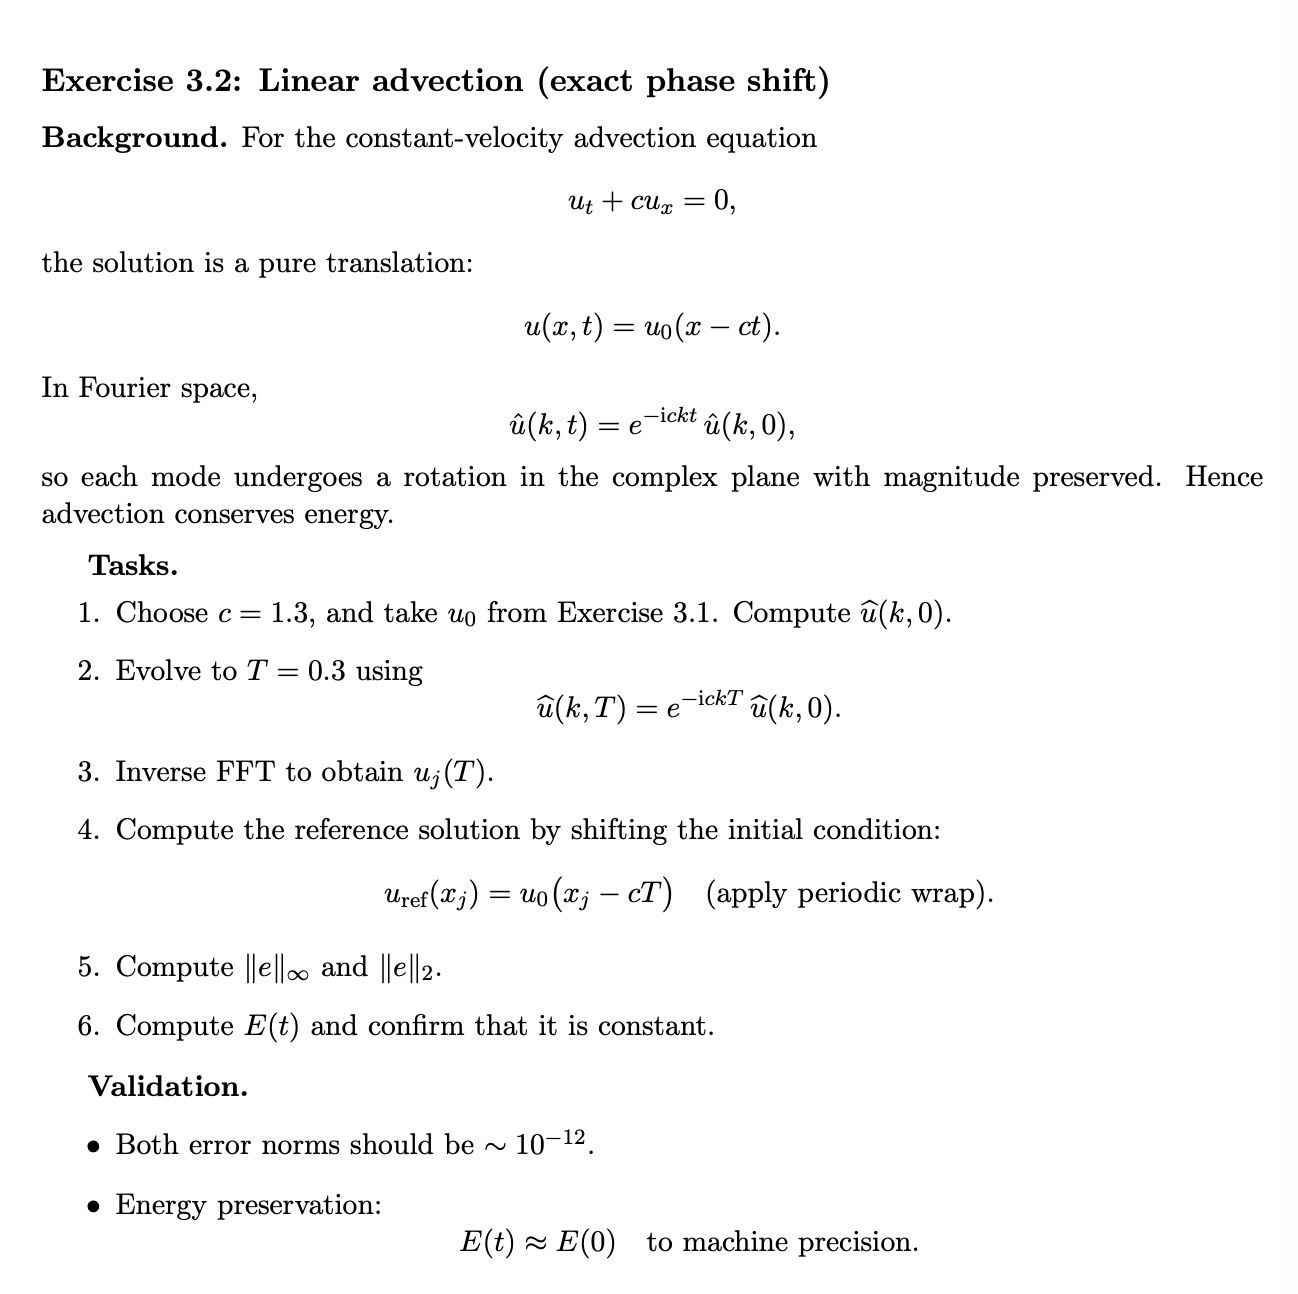

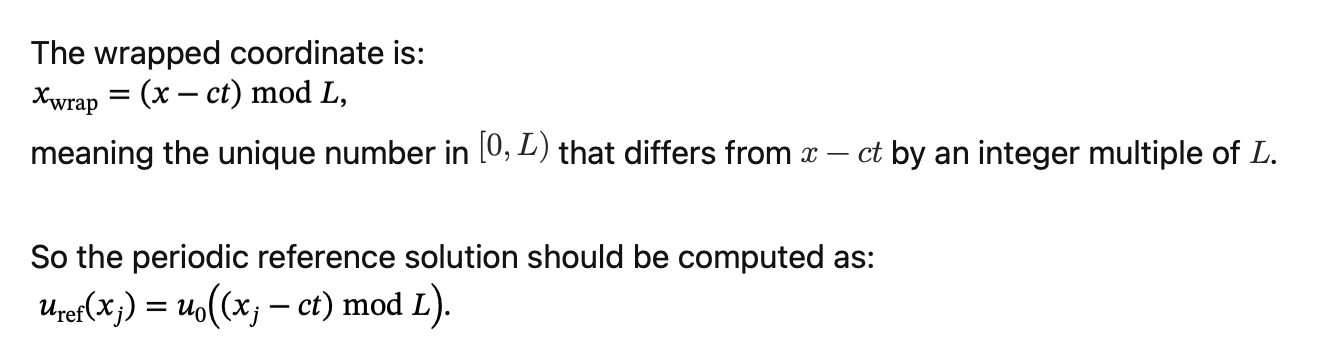

In [19]:
c = 1.3
T = 0.3
L=2*np.pi
N = 128

def u_0(x):
    return np.sin(5*x) + (1/2)*np.cos(9*x)

# Sampling + FFT 
x_j = np.arange(N) * (L/N)
sampled_array = u_0(x_j)
u_hat_k_n = np.fft.fft(sampled_array)

u_hat_k_T = np.exp(-1j * c * T * k_n) * u_hat_k_n
inv_u_hat = np.fft.ifft(u_hat_k_T)

# Reference solution
u_ref = u_0((x_j - c*T)%L) # Periodic wrap, 

# Errors - L2 and L_inf
error = u_ref - inv_u_hat
error_l2 = la.norm(error, ord=2)/np.sqrt(N)
error_inf = la.norm(error, ord=np.inf)

print(f"L2 norm of the error: {error_l2}")
print(f"L_inf norm of the error: {error_inf}")

# Energy 
E_t = (1/N)*np.sum(np.abs(u_ref)**2)
E_0 = (1/N)*np.sum(np.abs(u_0(x_j))**2)
print(f"Energy {E_t}")
print(f"E(0) = {E_0}")
print(f"Difference {abs(E_t - E_0)}")


L2 norm of the error: 2.155254203162318e-15
L_inf norm of the error: 9.326855074963882e-15
Energy 0.6250000000000001
E(0) = 0.625
Difference 1.1102230246251565e-16


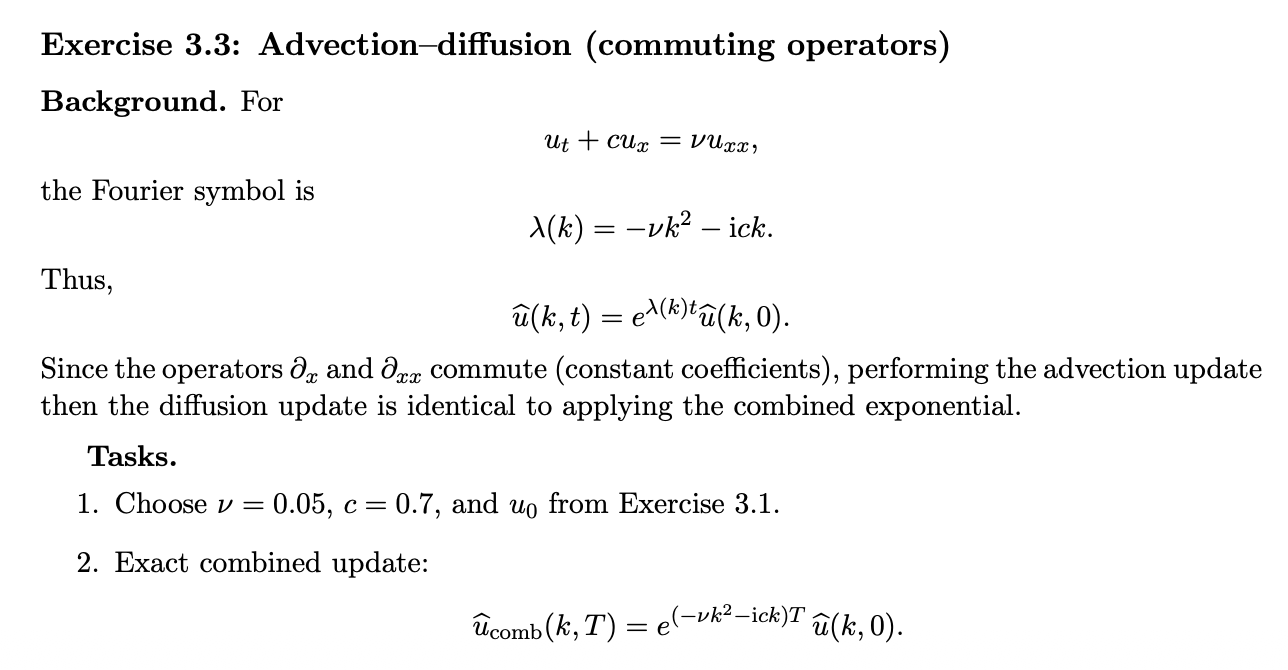
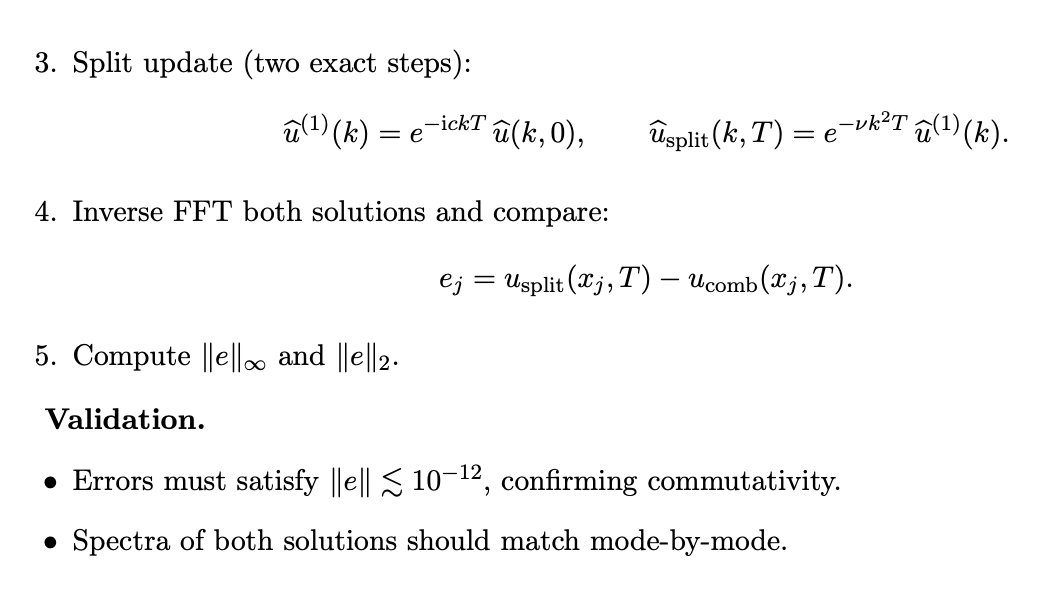

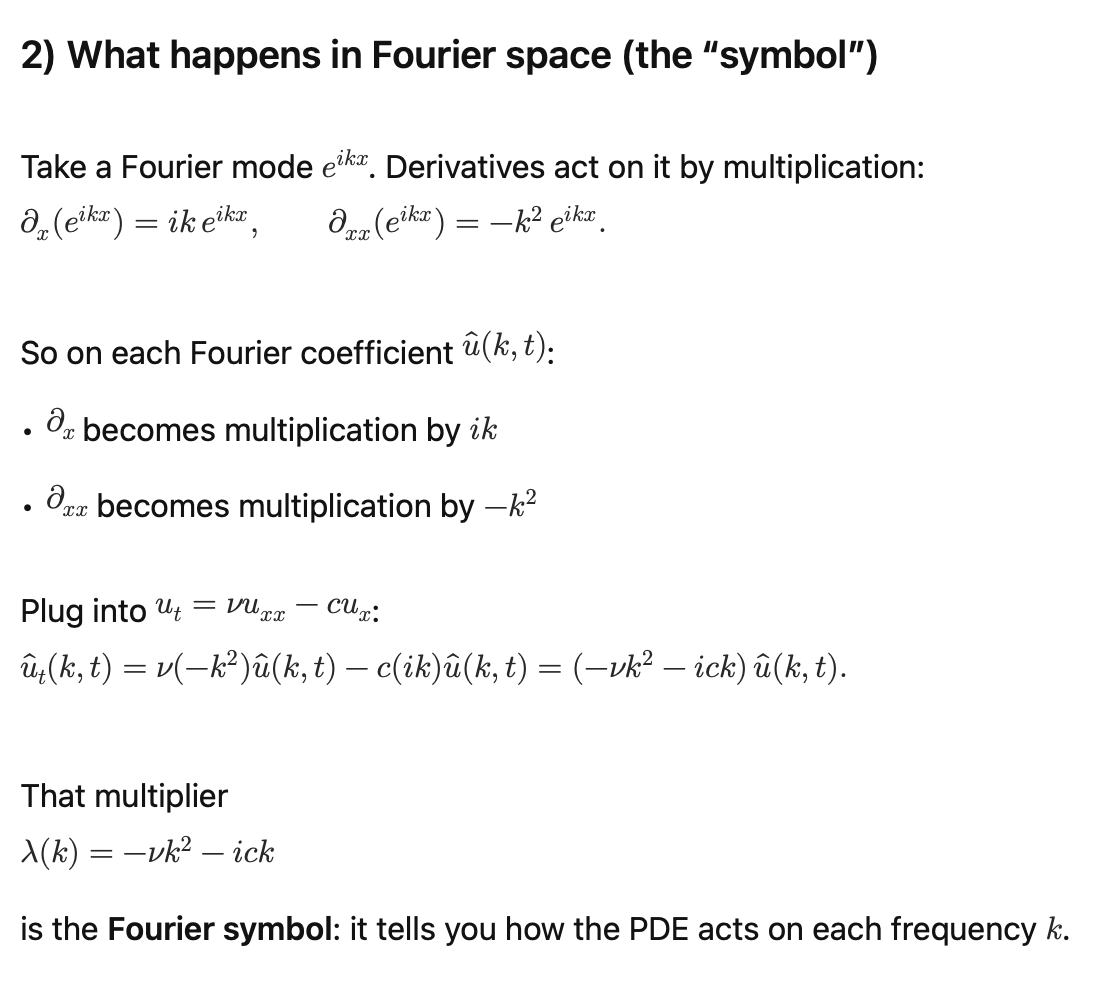
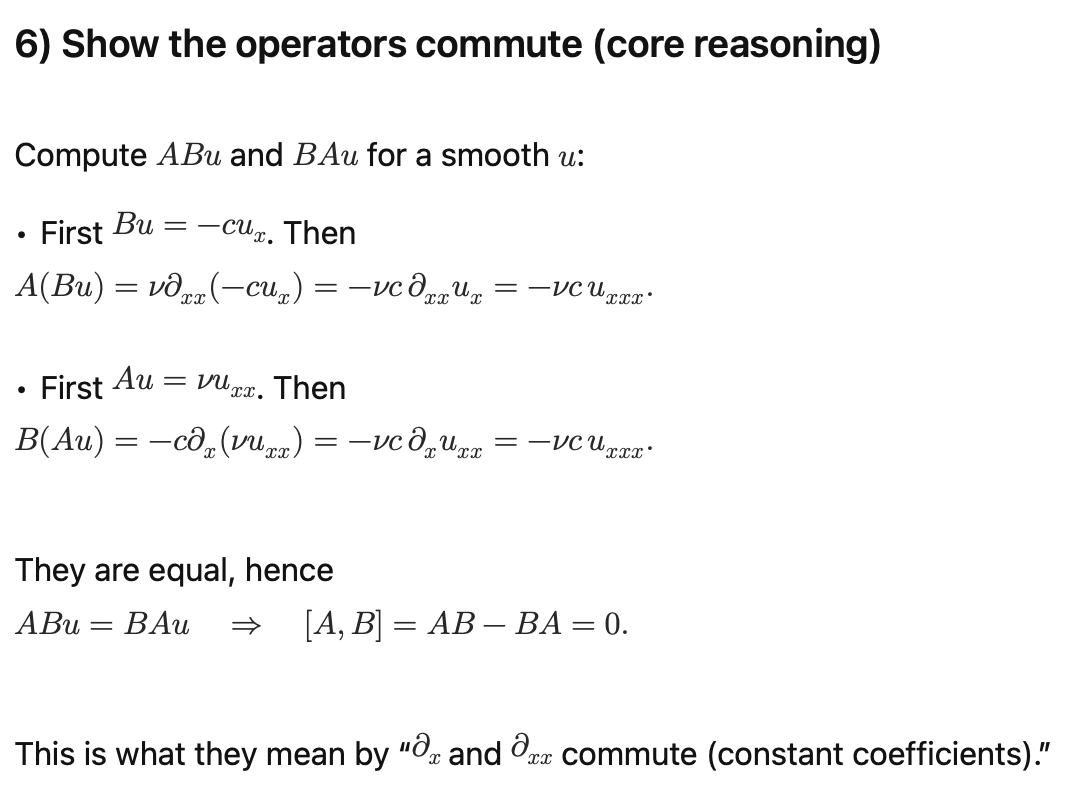
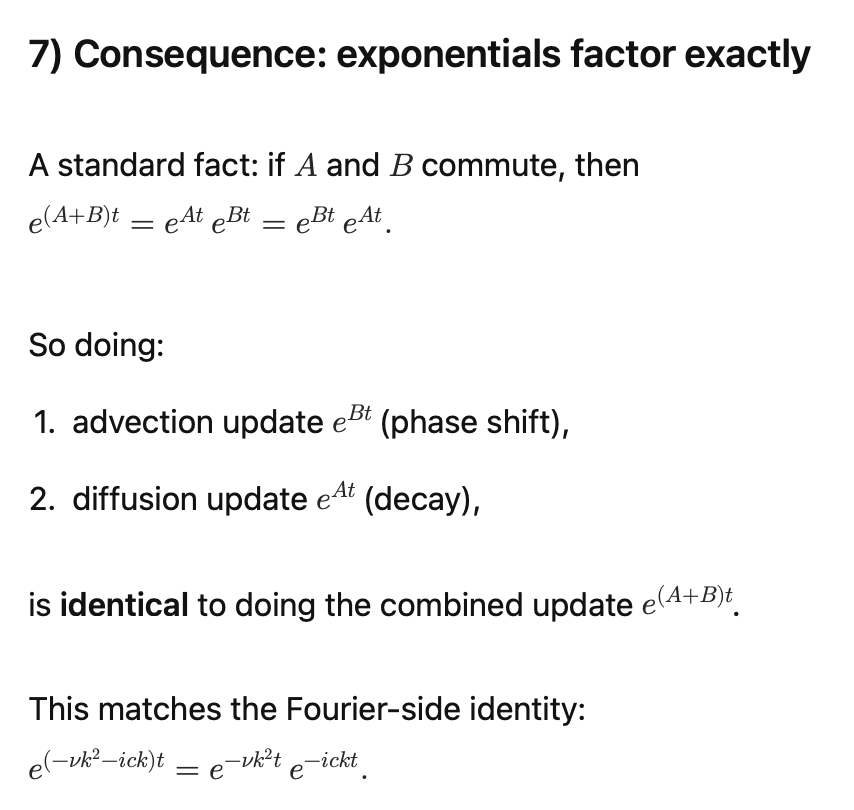

In [3]:
nu = 0.05
c = 0.7
T = 0.3
L=2*np.pi
N = 128
k_n = 2*np.pi*np.fft.fftfreq(N,L/N)

def u_0(x):
    return np.sin(5*x) + (1/2)*np.cos(9*x)

# Sampling + FFT 
x_j = np.arange(N) * (L/N)
sampled_array = u_0(x_j)
u_hat_k_n = np.fft.fft(sampled_array)

# Exact combined update
u_hat_comb = np.exp(((-nu*k_n**2) - 1j*c*k_n)*T)*u_hat_k_n

# Split update
u_hat_1_k = np.exp(-1j*c*k_n*T)*u_hat_k_n
u_hat_split_k_T = np.exp(-nu*k_n**2*T)*u_hat_1_k

# Inverse FFT
u_hat_comb_inv = np.fft.ifft(u_hat_comb)
u_hat_split_k_T_inv = np.fft.ifft(u_hat_split_k_T)

# Error
error = u_hat_split_k_T_inv - u_hat_comb_inv
error_l2 = la.norm(error, ord=2)/np.sqrt(N)
error_inf = la.norm(error, ord=np.inf)

print(f"L2 norm of the error: {error_l2}")
print(f"L_inf norm of the error: {error_inf}")


L2 norm of the error: 8.589317577450982e-17
L_inf norm of the error: 1.9229626863835638e-16


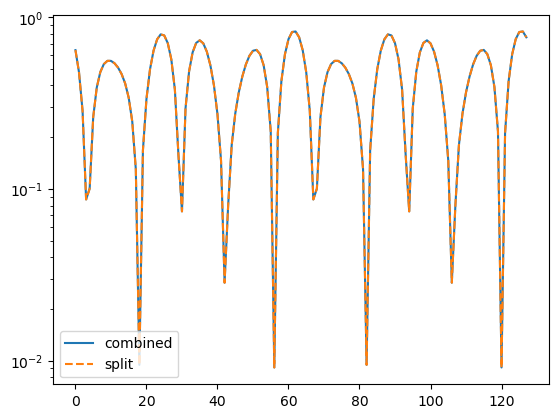

In [ ]:
# Mode-by-mode match check (the two curves overlap)

plt.semilogy(np.abs(u_hat_comb_inv), label="combined")
plt.semilogy(np.abs(u_hat_split_k_T_inv), '--', label="split")
plt.legend()
plt.show()

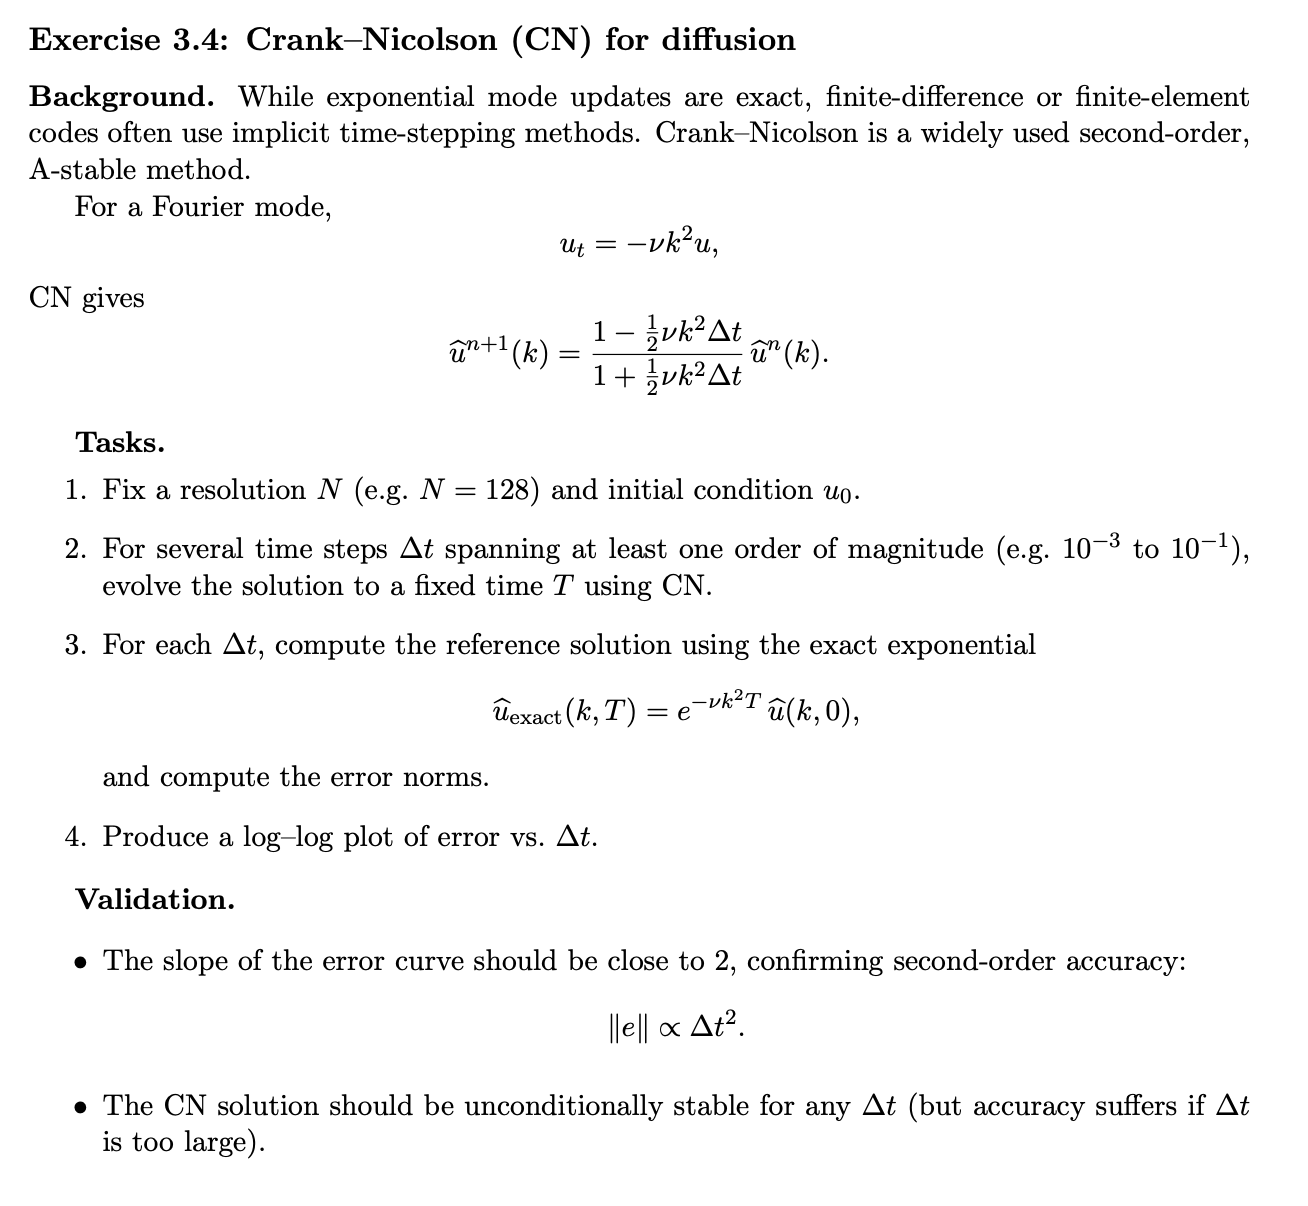

In [26]:
nu = 0.05
T = 0.5
L=2*np.pi
N = 128
k_n = 2*np.pi*np.fft.fftfreq(N,L/N)
error_dict = dict()

def u_0(x):
    return np.sin(5*x) + (1/2)*np.cos(9*x)

# Sampling + FFT 
x_j = np.arange(N) * (L/N)
sampled_array = u_0(x_j)
u_hat_k_n = np.fft.fft(sampled_array)

# Evolving the solution using Crank Nicolson scheme
for N_t in [50,100,200,300,400,500,600]:
    delta_t = T/N_t
    print(f"Delta t is {delta_t}")
    u_hat_n = u_hat_k_n

    for n in range(0,N_t):
        u_hat_k = ((1 - 0.5*nu*k_n**2*delta_t)/(1 + 0.5*nu*k_n**2*delta_t))*u_hat_n
        u_hat_n = u_hat_k

    u_cn_fft = np.fft.ifft(u_hat_k).real
    u_exact = np.exp(-nu*k_n**2*T)*u_hat_k_n
    u_exact_inv = np.fft.ifft(u_exact).real

    # Error
    error = u_exact_inv - u_cn_fft
    error_l2 = la.norm(error, ord=2)/np.sqrt(N)
    error_inf = la.norm(error, ord=np.inf)
    error_dict[delta_t] = error_l2

    print(f"L2 norm of the error: {error_l2}")
    print(f"L_inf norm of the error: {error_inf}")


Delta t is 0.01
L2 norm of the error: 1.3280552236462385e-05
L_inf norm of the error: 2.2556297974873907e-05
Delta t is 0.005
L2 norm of the error: 3.319881824390993e-06
L_inf norm of the error: 5.638690536602375e-06
Delta t is 0.0025
L2 norm of the error: 8.2995444116127e-07
L_inf norm of the error: 1.4096486294912225e-06
Delta t is 0.0016666666666666668
L2 norm of the error: 3.688673214606393e-07
L_inf norm of the error: 6.265085253920333e-07
Delta t is 0.00125
L2 norm of the error: 2.0748760738735988e-07
L_inf norm of the error: 3.5241063889301927e-07
Delta t is 0.001
L2 norm of the error: 1.32791998846091e-07
L_inf norm of the error: 2.255427383746067e-07
Delta t is 0.0008333333333333334
L2 norm of the error: 9.221663020568766e-08
L_inf norm of the error: 1.566268117425551e-07


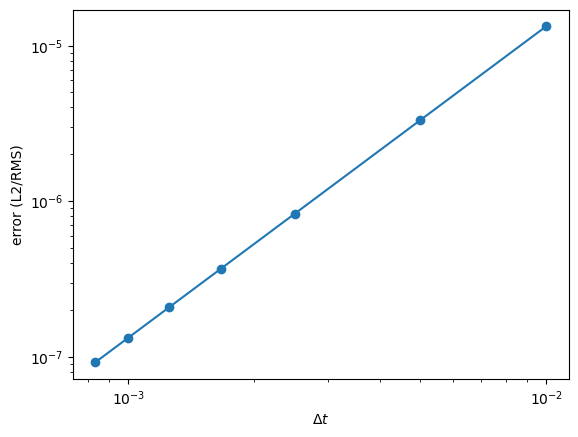

In [29]:
dts = np.array(sorted(error_dict.keys()))
errs = np.array([error_dict[dt] for dt in dts])
plt.loglog(dts, errs, marker="o")
plt.xlabel(r"$\Delta t$")
plt.ylabel("error (L2/RMS)")
plt.show()

In [24]:
list(error_dict.keys())

[0.01, 0.005, 0.0025, 0.0016666666666666668, 0.00125]

In [ ]:
list(error_dict.values())

0.01